In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

In [4]:
if "Person ID" in df.columns:
       df.drop(columns=["Person ID"], inplace=True)

In [5]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})


# Split Blood Pressure
if "Blood Pressure" in df.columns:
       df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split('/', expand=True).astype(int)
       df.drop(columns=["Blood Pressure"], inplace=True)

In [6]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


In [8]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
transformers=[
("num", StandardScaler(), numerical_cols),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]
)

In [9]:
rf_model = Pipeline([
("preprocessor", preprocessor),
("classifier", RandomForestClassifier(
n_estimators=200,
random_state=42
))
])

In [10]:
xgb_model = Pipeline([
("preprocessor", preprocessor),
("classifier", XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=5,
eval_metric='mlogloss',
random_state=42
))
])

In [11]:
voting_clf = VotingClassifier(
estimators=[
('rf', rf_model),
('xgb', xgb_model)
],
voting='soft'
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded,
test_size=0.2,
stratify=y_encoded,
random_state=42
)

In [13]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                Index(['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
       'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP',
       'Diastolic_BP'],
      dtype='object')),
                                                                               ('cat',
                                                                                OneHotEncoder(handle_unknown='ignore'),
                                                                                Index(['Gender', 'Occupati...
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.05,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=200,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...))]))],
                 voting='soft')

In [14]:
y_pred = voting_clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Final Accuracy: 93.33%

Classification Report:

              precision    recall  f1-score   support

    Insomnia       0.78      0.93      0.85        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.93        75
   macro avg       0.90      0.91      0.90        75
weighted avg       0.94      0.93      0.93        75

Confusion Matrix:

[[14  0  1]
 [ 1 43  0]
 [ 3  0 13]]


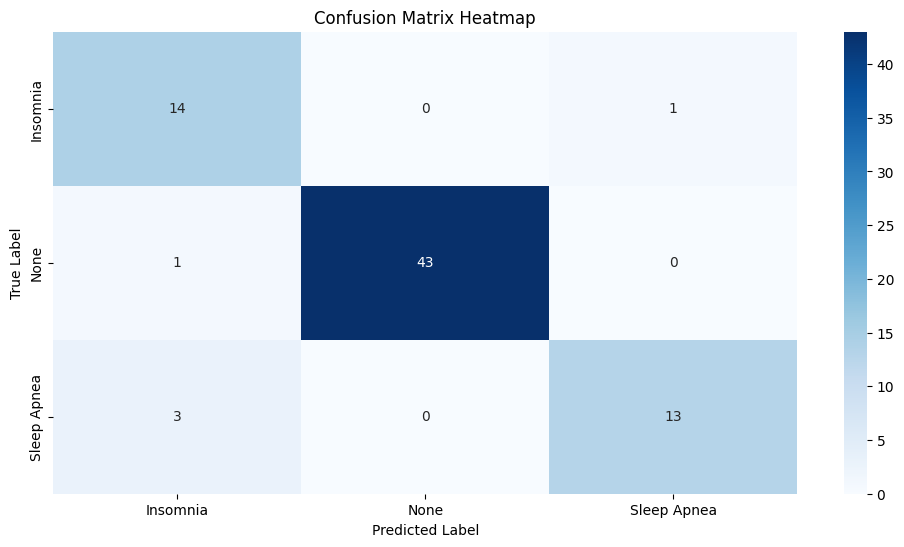

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=le.classes_,
yticklabels=le.classes_)


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## XAI: Feature Importance, SHAP, and LIME

In [16]:
# Install/verify XAI dependencies used below.
import importlib.util
import subprocess
import sys

required_packages = {
    "shap": "shap==0.46.0",
    "lime": "lime",
}

for import_name, package_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import shap
from lime.lime_tabular import LimeTabularExplainer

print("XAI packages ready")
print("SHAP version:", shap.__version__)

XAI packages ready
SHAP version: 0.46.0


In [17]:
# Prepare transformed feature matrix and fitted estimators for XAI.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

rf_pipeline = voting_clf.named_estimators_["rf"]
xgb_pipeline = voting_clf.named_estimators_["xgb"]

fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_classifier = rf_pipeline.named_steps["classifier"]
xgb_classifier = xgb_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

X_train_xai = to_dense(X_train_processed)
X_test_xai = to_dense(X_test_processed)

sample_size = min(50, X_test_xai.shape[0])
X_shap_sample = X_test_xai[:sample_size]

print("Transformed train shape:", X_train_xai.shape)
print("Transformed test shape:", X_test_xai.shape)
print("Number of XAI features:", len(feature_names))
print("Class labels:", list(le.classes_))

Transformed train shape: (299, 25)
Transformed test shape: (75, 25)
Number of XAI features: 25
Class labels: ['Insomnia', 'None', 'Sleep Apnea']


Top 15 global feature importances:


,feature,random_forest_importance,xgboost_importance,mean_importance
0,cat__BMI Category_Normal,0.115746,0.700890,0.408318
1,num__Systolic_BP,0.138850,0.123480,0.131165
2,cat__BMI Category_Overweight,0.128236,0.002020,0.065128
3,num__Diastolic_BP,0.104175,0.013382,0.058778
4,num__Physical Activity Level,0.049754,0.064994,0.057374
5,num__Sleep Duration,0.097824,0.003704,0.050764
6,num__Age,0.095972,0.004352,0.050162
7,cat__Occupation_Nurse,0.055603,0.021705,0.038654
8,num__Heart Rate,0.048030,0.022204,0.035117
9,num__Daily Steps,0.044386,0.006225,0.025305


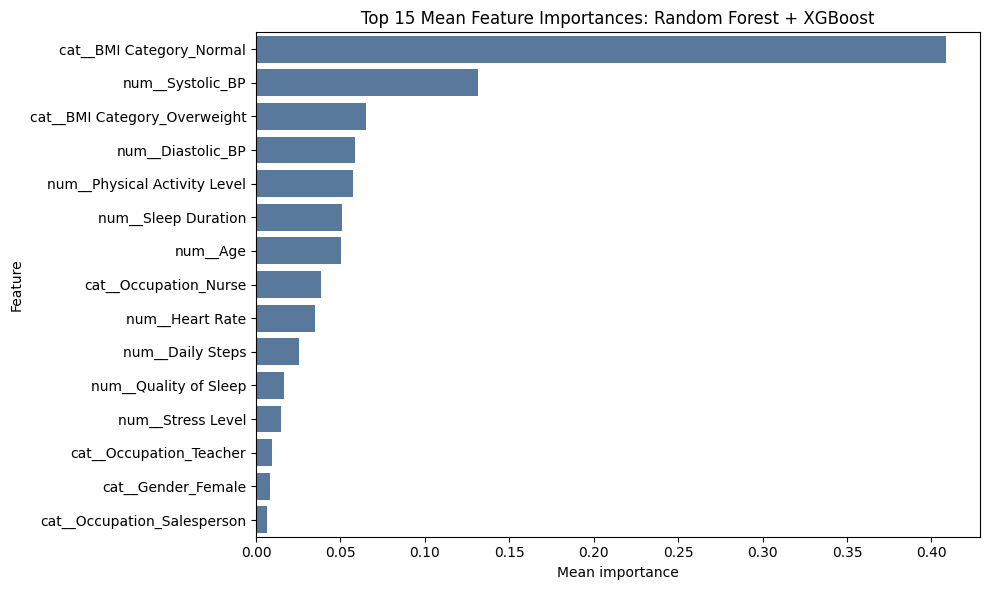

In [18]:
# Global feature importance from Random Forest and XGBoost inside the voting ensemble.
rf_importance = rf_classifier.feature_importances_
xgb_importance = xgb_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "random_forest_importance": rf_importance,
    "xgboost_importance": xgb_importance,
})
importance_df["mean_importance"] = importance_df[[
    "random_forest_importance",
    "xgboost_importance"
]].mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False).reset_index(drop=True)

print("Top 15 global feature importances:")
display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="mean_importance",
    y="feature",
    color="#4C78A8",
)
plt.title("Top 15 Mean Feature Importances: Random Forest + XGBoost")
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

SHAP calculated on 50 test rows using the fitted XGBoost model.
Top 15 SHAP features:


,feature,mean_abs_shap,shap_Insomnia,shap_None,shap_Sleep Apnea
0,num__Systolic_BP,0.808354,0.606275,0.936423,0.882365
1,num__Age,0.399244,0.466025,0.349255,0.382452
2,num__Physical Activity Level,0.341988,0.873797,0.010259,0.141909
3,num__Sleep Duration,0.251761,0.304112,0.275568,0.175601
4,cat__BMI Category_Normal,0.233941,0.000000,0.689871,0.011952
5,num__Daily Steps,0.166188,0.227561,0.142654,0.128350
6,num__Heart Rate,0.156977,0.062499,0.075523,0.332910
7,num__Diastolic_BP,0.076348,0.048672,0.001735,0.178635
8,num__Quality of Sleep,0.076017,0.105417,0.068414,0.054220
9,cat__Occupation_Accountant,0.075276,0.216052,0.009776,0.000000


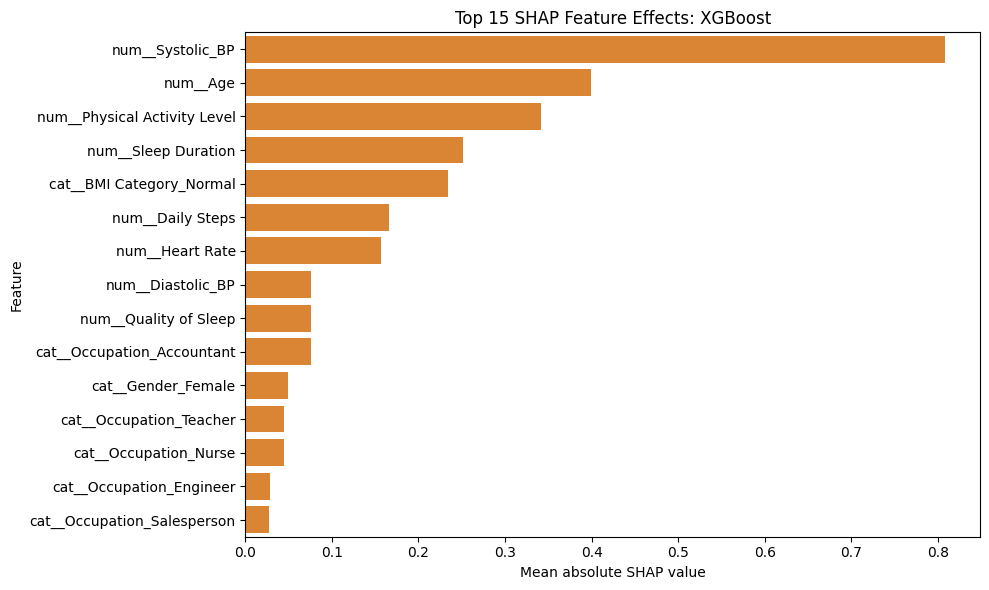

SHAP summary plot for class: Insomnia


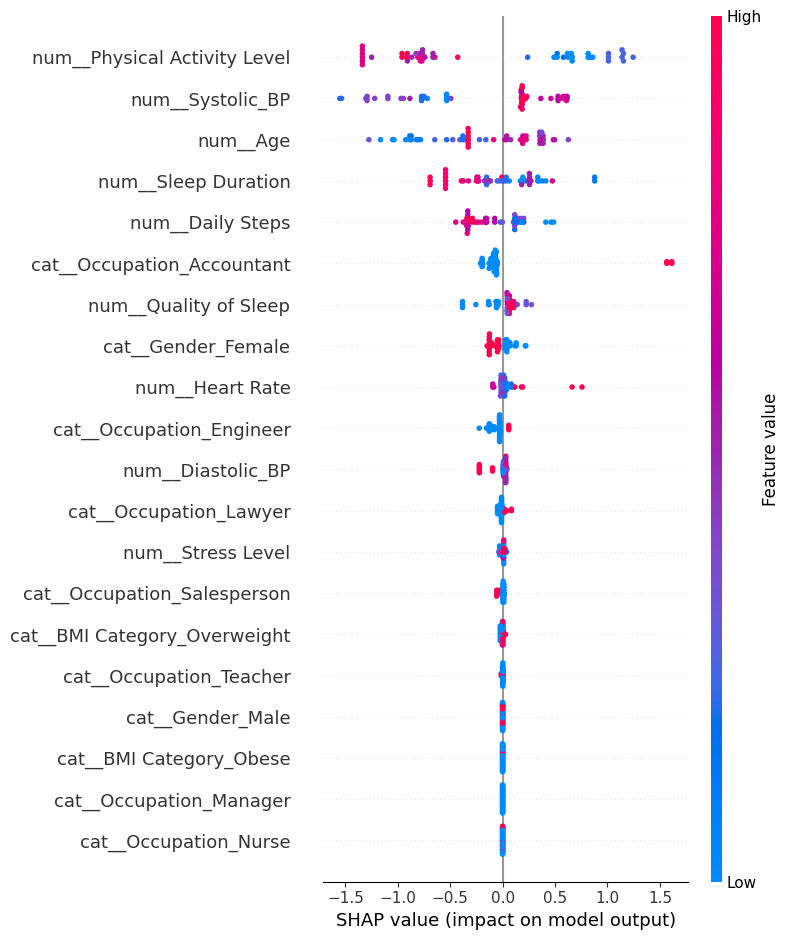

In [19]:
# SHAP global explanation for the fitted XGBoost model.
shap_explainer = shap.TreeExplainer(xgb_classifier)
shap_values = shap_explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_array = np.stack(shap_values, axis=-1)
else:
    shap_array = np.asarray(shap_values)

if shap_array.ndim == 3:
    mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
    shap_class_details = {
        f"shap_{class_name}": np.abs(shap_array[:, :, class_idx]).mean(axis=0)
        for class_idx, class_name in enumerate(le.classes_)
    }
else:
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    shap_class_details = {}

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
    **shap_class_details,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(f"SHAP calculated on {sample_size} test rows using the fitted XGBoost model.")
print("Top 15 SHAP features:")
display(shap_importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=shap_importance_df.head(15),
    x="mean_abs_shap",
    y="feature",
    color="#F58518",
)
plt.title("Top 15 SHAP Feature Effects: XGBoost")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Beeswarm-style summary for the predicted class of the first explained row.
if shap_array.ndim == 3:
    explained_class_idx = int(xgb_classifier.predict(X_shap_sample[:1])[0])
    print("SHAP summary plot for class:", le.classes_[explained_class_idx])
    shap.summary_plot(
        shap_array[:, :, explained_class_idx],
        X_shap_sample,
        feature_names=feature_names,
        show=False,
    )
else:
    shap.summary_plot(shap_array, X_shap_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

Combined LIME explanation for test instance: 0
Actual class: Insomnia
Predicted class: Insomnia
Prediction probabilities:


,Insomnia,None,Sleep Apnea
0,0.986588,0.012022,0.00139


Combined LIME rules for all Sleep Disorder classes:


,class,rank,feature_rule,lime_weight,effect
0,Insomnia,1,num__Physical Activity Level <= -0.70,0.144209,supports class
1,Insomnia,2,0.19 < num__Systolic_BP <= 0.84,0.106712,supports class
2,Insomnia,3,cat__Occupation_Sales Representative <= 0.00,0.064088,supports class
3,Insomnia,4,cat__BMI Category_Normal <= 0.00,0.057554,supports class
4,Insomnia,5,cat__Occupation_Accountant <= 0.00,-0.056332,opposes class
5,Insomnia,6,num__Daily Steps <= -0.54,0.046049,supports class
6,Insomnia,7,0.06 < num__Diastolic_BP <= 0.86,0.037816,supports class
7,Insomnia,8,cat__Occupation_Manager <= 0.00,0.036932,supports class
8,Insomnia,9,0.00 < cat__BMI Category_Overweight <= 1.00,0.030232,supports class
9,Insomnia,10,0.09 < num__Age <= 0.90,0.029313,supports class


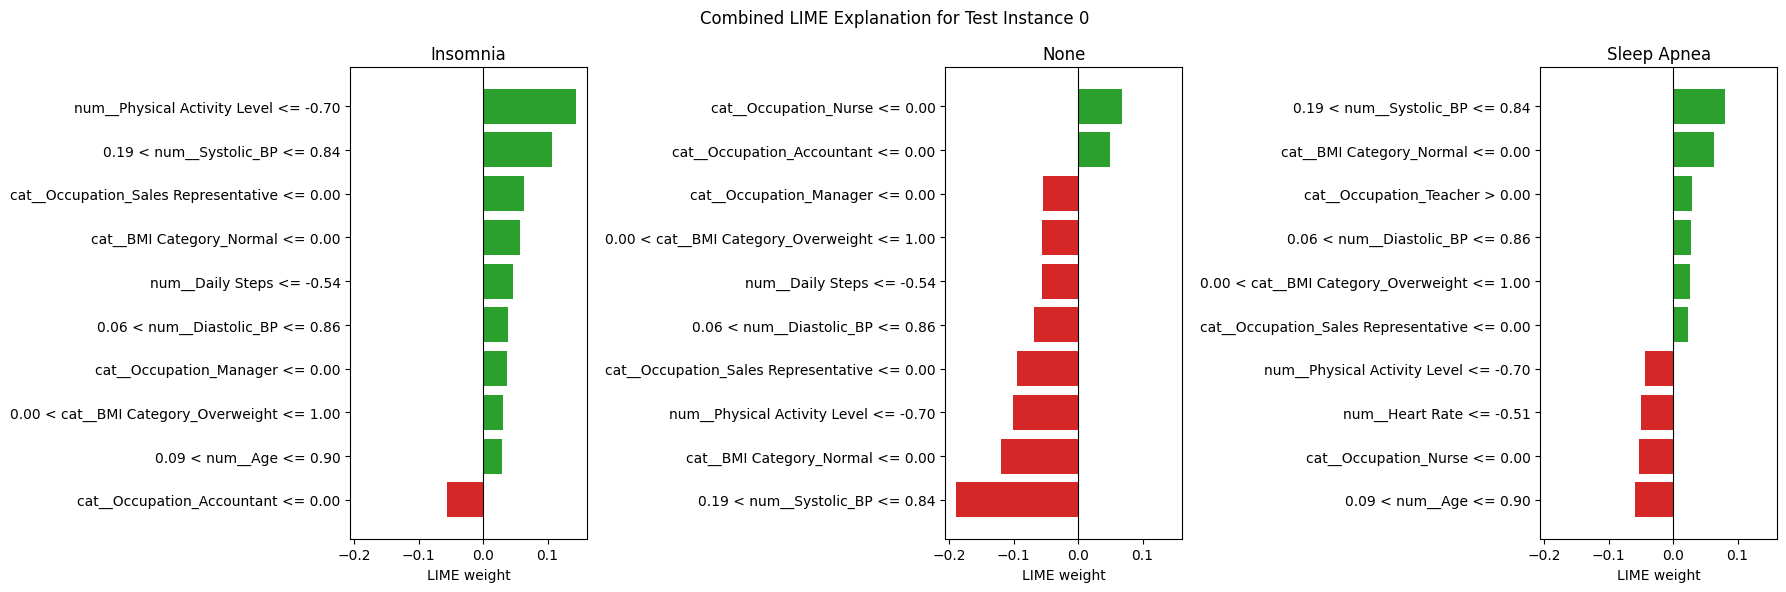

In [20]:
# Combined LIME local explanations for all Sleep Disorder classes using the soft-voting ensemble probabilities.
def ensemble_predict_proba_processed(data):
    data = np.asarray(data)
    return (
        rf_classifier.predict_proba(data) +
        xgb_classifier.predict_proba(data)
    ) / 2

lime_explainer = LimeTabularExplainer(
    training_data=X_train_xai,
    feature_names=list(feature_names),
    class_names=list(le.classes_),
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

instance_idx = 0
instance = X_test_xai[instance_idx]
predicted_class_idx = int(voting_clf.predict(X_test.iloc[[instance_idx]])[0])
predicted_label = le.classes_[predicted_class_idx]
actual_label = le.classes_[y_test[instance_idx]]

lime_exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=ensemble_predict_proba_processed,
    num_features=10,
    labels=list(range(len(le.classes_))),
)

probability_df = pd.DataFrame(
    [ensemble_predict_proba_processed(instance.reshape(1, -1))[0]],
    columns=le.classes_,
)

combined_lime_rows = []
for class_idx, class_name in enumerate(le.classes_):
    for rank, (feature_rule, lime_weight) in enumerate(lime_exp.as_list(label=class_idx), start=1):
        combined_lime_rows.append({
            "class": class_name,
            "rank": rank,
            "feature_rule": feature_rule,
            "lime_weight": lime_weight,
            "effect": "supports class" if lime_weight > 0 else "opposes class",
        })

combined_lime_df = pd.DataFrame(combined_lime_rows)

print("Combined LIME explanation for test instance:", instance_idx)
print("Actual class:", actual_label)
print("Predicted class:", predicted_label)
print("Prediction probabilities:")
display(probability_df)

print("Combined LIME rules for all Sleep Disorder classes:")
display(combined_lime_df)

plot_lime_df = combined_lime_df.copy()
plot_lime_df["feature_short"] = plot_lime_df["feature_rule"].str.slice(0, 55)

classes = list(le.classes_)
fig, axes = plt.subplots(1, len(classes), figsize=(18, 6), sharex=True)
if len(classes) == 1:
    axes = [axes]

for ax, class_name in zip(axes, classes):
    class_df = plot_lime_df[plot_lime_df["class"] == class_name].sort_values("lime_weight")
    colors = class_df["lime_weight"].apply(lambda value: "#2ca02c" if value > 0 else "#d62728")
    ax.barh(class_df["feature_short"], class_df["lime_weight"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(class_name)
    ax.set_xlabel("LIME weight")
    ax.set_ylabel("")

plt.suptitle(f"Combined LIME Explanation for Test Instance {instance_idx}")
plt.tight_layout()
plt.show()